### Escuela Politécnica Nacional ###

**Nombre:** Kevin Eduardo Garcia Rodriguez

**Tema:** [Taller 3b] Gauss Jacobi y Gauss Seidel

**Repositorio GIT:** https://github.com/Nattyrd/Metodos-Numericos-2025B

In [5]:
%load_ext autoreload
%autoreload 2
from src import eliminacion_gaussiana, gauss_jacobi, gauss_seidel
import numpy as np

[01-20 20:59:39][INFO][NattyrdGT] 2026-01-20 20:59:39.066448
[01-20 20:59:39][INFO][NattyrdGT] 2026-01-20 20:59:39.069920


### EJERCICIO 1

![Descripción](img1.png)


### 1.1 Metodo Gauss Seidel

In [7]:
x=[0,0]
A=np.array([[1, 1],
            [-2, 5]], dtype=float)
b=np.array([7, 0], dtype=float)
n=2
solution, historial_x_solutions = gauss_seidel(A=A, b=b, x=[0] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:00:02][INFO][NattyrdGT] i= 0 x: [[0. 0.]]
[01-20 21:00:02][INFO][NattyrdGT] i= 1 x: [[7.  2.8]]


[01-20 21:00:02][INFO][NattyrdGT] i= 2 x: [[4.2  1.68]]
[01-20 21:00:02][INFO][NattyrdGT] i= 3 x: [[5.32  2.128]]
[01-20 21:00:02][INFO][NattyrdGT] i= 4 x: [[4.872  1.9488]]
[01-20 21:00:02][INFO][NattyrdGT] i= 5 x: [[5.0512  2.02048]]
[01-20 21:00:02][INFO][NattyrdGT] i= 6 x: [[4.97952  1.991808]]
[01-20 21:00:02][INFO][NattyrdGT] i= 7 x: [[5.008192  2.0032768]]
[01-20 21:00:02][INFO][NattyrdGT] i= 8 x: [[4.9967232  1.99868928]]
[01-20 21:00:02][INFO][NattyrdGT] i= 9 x: [[5.00131072 2.00052429]]
[01-20 21:00:02][INFO][NattyrdGT] i= 10 x: [[4.99947571 1.99979028]]


In [36]:
n2=1
solution_seidel, historial_x_solutions_Seidel_S2 = gauss_seidel(A=A, b=b, x=[100,20] * n2, tol=1e-5, max_iter=10)  # type: ignore

[01-20 17:43:15][INFO][NattyrdGT] i= 0 x: [[100.  20.]]
[01-20 17:43:15][INFO][NattyrdGT] i= 1 x: [[-13.   -5.2]]
[01-20 17:43:15][INFO][NattyrdGT] i= 2 x: [[12.2   4.88]]
[01-20 17:43:16][INFO][NattyrdGT] i= 3 x: [[2.12  0.848]]
[01-20 17:43:16][INFO][NattyrdGT] i= 4 x: [[6.152  2.4608]]
[01-20 17:43:16][INFO][NattyrdGT] i= 5 x: [[4.5392  1.81568]]
[01-20 17:43:16][INFO][NattyrdGT] i= 6 x: [[5.18432  2.073728]]
[01-20 17:43:16][INFO][NattyrdGT] i= 7 x: [[4.926272  1.9705088]]
[01-20 17:43:16][INFO][NattyrdGT] i= 8 x: [[5.0294912  2.01179648]]
[01-20 17:43:16][INFO][NattyrdGT] i= 9 x: [[4.98820352 1.99528141]]
[01-20 17:43:16][INFO][NattyrdGT] i= 10 x: [[5.00471859 2.00188744]]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_historial_x_nuevo(historial_x):
    """
    Grafica la trayectoria de las soluciones en el plano X1 vs X2
    mostrando cómo se mueven los valores en cada iteración.

    Parameters
    ----------
    historial_x : list
        Lista de vectores x obtenidos en cada iteración.
        Cada x debe ser de la forma [x1, x2]
    """

    historial_x = np.array(historial_x)

    if historial_x.shape[1] != 2:
        raise ValueError("Este método solo funciona para vectores de 2 variables (x1, x2)")

    x1 = historial_x[:, 0]
    x2 = historial_x[:, 1]

    plt.plot(x1, x2, marker='o')
    
    # Etiquetar cada punto con la iteración
    for i in range(len(x1)):
        plt.text(x1[i], x2[i], f'{i}', fontsize=9)

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Trayectoria del vector solución (X1 vs X2)')
    plt.grid(True)
    plt.show()


In [58]:
def graficar_historial_x(historial_x):
    """
    Grafica la evolución de cada componente del vector x (de soluciones)
    a lo largo de las iteraciones.

    Parameters
    ----------
    historial_x : list
        Lista de vectores x obtenidos en cada iteración
    """

    historial_x = np.array(historial_x)  # shape: (iteraciones, n)

    iteraciones = range(len(historial_x))
    n_variables = historial_x.shape[1]

    for i in range(n_variables):
        plt.plot(iteraciones, historial_x[:, i], label=f'x{i+1}')

    plt.xlabel('Iteraciones')
    plt.ylabel('Valor de x')
    plt.title('Convergencia de las variables ')
    plt.legend()
    plt.grid(True)
    plt.show()


### Graficar Con Gauss Seidel

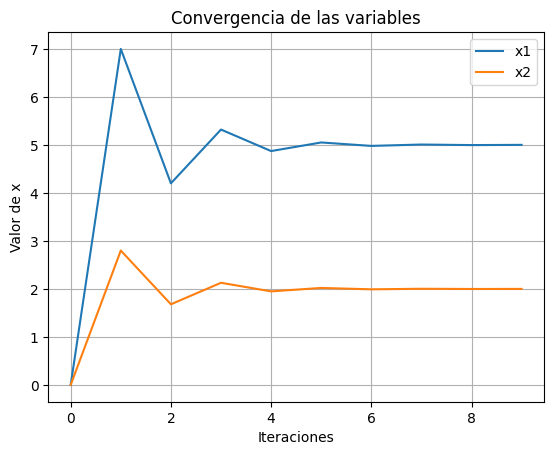

In [39]:
graficar_historial_x(historial_x_solutions)

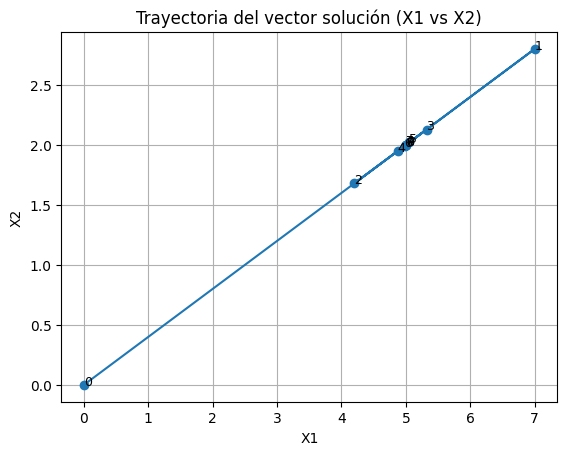

In [42]:
graficar_historial_x_nuevo(historial_x_solutions)

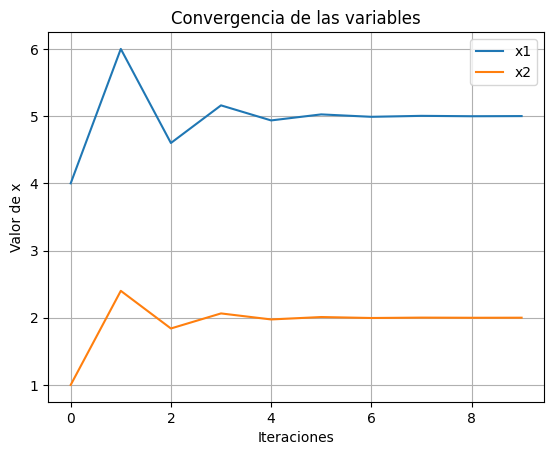

In [23]:
graficar_historial_x(historial_x_solutions_Seidel_S2)

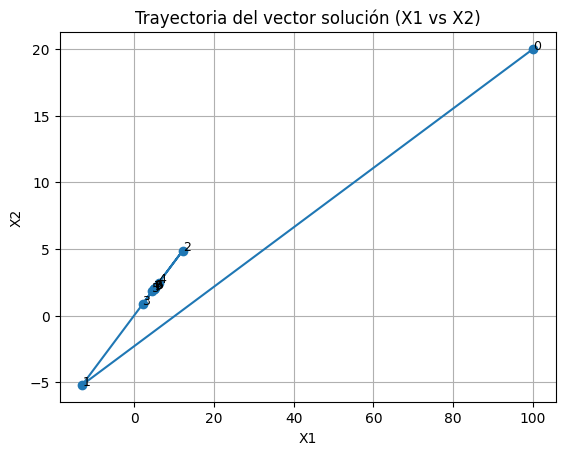

In [43]:
graficar_historial_x_nuevo(historial_x_solutions_Seidel_S2)

### 1.2 Metodo de Gauss Jacobi

In [10]:
solution_jacobi, historial_x_solutions_jacobi = gauss_jacobi(A=A, b=b, x=[0] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:00:22][INFO][NattyrdGT] i= 0 x: [[0. 0.]]
[01-20 21:00:22][INFO][NattyrdGT] i= 10 x: [[5.0512  2.02048]]


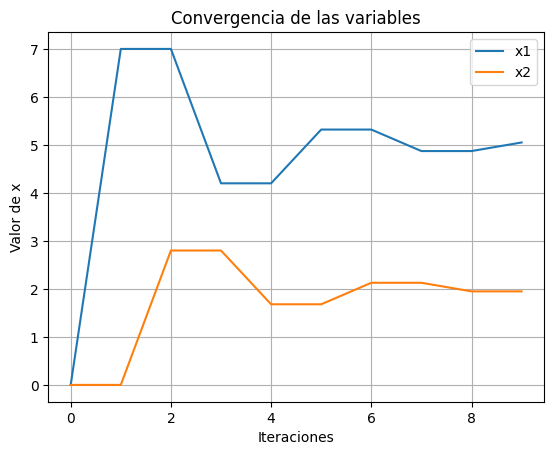

In [25]:
graficar_historial_x(historial_x_solutions_jacobi)

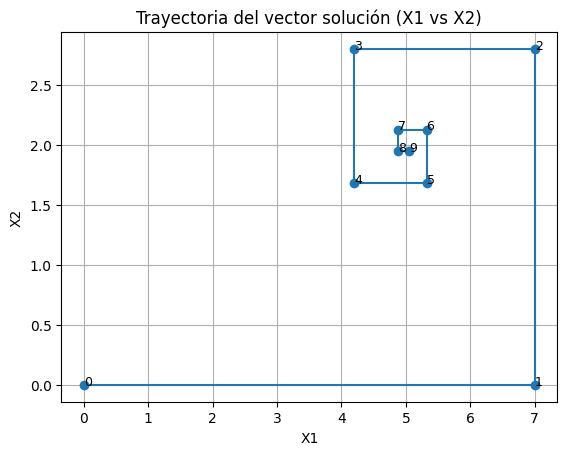

In [44]:
graficar_historial_x_nuevo(historial_x_solutions_jacobi)

In [14]:
n1=1
solution_jacobi_S2, historial_x_solutions_jacobi_S2 = gauss_jacobi(A=A, b=b, x=[4,2] * n1, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:01:44][INFO][NattyrdGT] i= 0 x: [[4. 2.]]
[01-20 21:01:44][INFO][NattyrdGT] i= 10 x: [[5.01024 2.     ]]


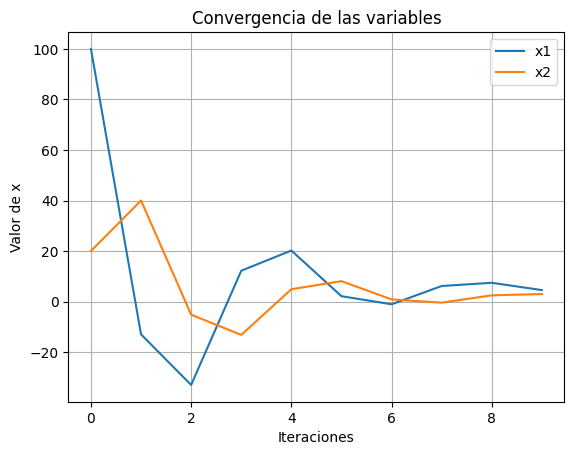

In [32]:
graficar_historial_x(historial_x_solutions_jacobi_S2)

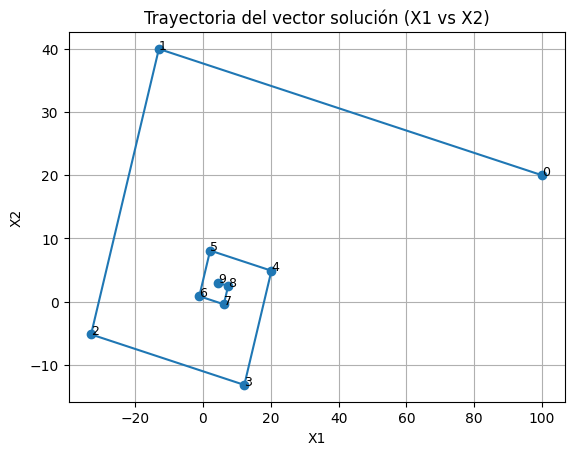

In [33]:
graficar_historial_x_nuevo(historial_x_solutions_jacobi_S2)

Como es la respuesta, Entonces no tenemos puntos que graficar ya que lo encuentra en la primera iteracion.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_multiples_historiales(historiales, etiquetas):
    """
    Grafica varias trayectorias X1 vs X2 en un mismo plano
    para comparar distintos métodos o condiciones iniciales.

    Parameters
    ----------
    historiales : list
        Lista de historiales_x.
        Cada historial_x es una lista de vectores [x1, x2]
    
    etiquetas : list
        Lista de etiquetas (nombres) para cada historial
        Ej: ["Jacobi", "Gauss-Seidel"]
    """

    if len(historiales) != len(etiquetas):
        raise ValueError("La cantidad de historiales y etiquetas debe coincidir")

    for historial_x, label in zip(historiales, etiquetas):
        historial_x = np.array(historial_x)

        if historial_x.shape[1] != 2:
            raise ValueError("Cada historial debe ser de 2 variables (x1, x2)")

        x1 = historial_x[:, 0]
        x2 = historial_x[:, 1]

        plt.plot(x1, x2, marker='o', label=label)

        # Etiquetar cada iteración
        for i in range(len(x1)):
            plt.text(x1[i], x2[i], f'{i}', fontsize=8)

    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Comparación de trayectorias X1 vs X2')
    plt.legend()
    plt.grid(True)
    plt.show()


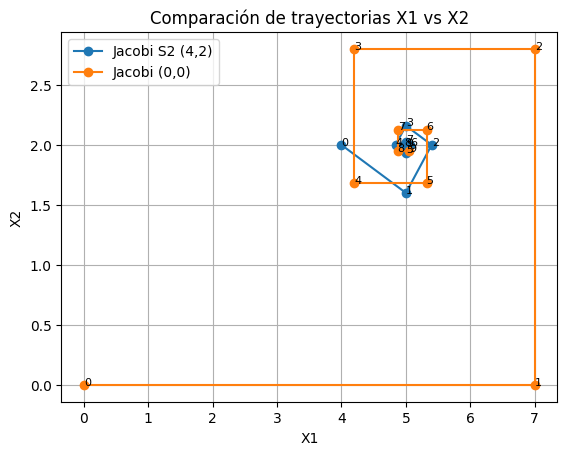

In [16]:
graficar_multiples_historiales(
    [historial_x_solutions_jacobi_S2, historial_x_solutions_jacobi],
    ["Jacobi S2 (4,2)", "Jacobi (0,0)"]
)


### EJERCICIO 2

![Descripción](img2.png)


### Metodo Gauss-Jacobi

In [39]:
A=np.array([[1, 1],
            [-2, 1]], dtype=float)
b=np.array([6, 0], dtype=float)
n=1
solution22, historial_x_solutions_jacobi2 = gauss_jacobi(A=A, b=b, x=[3,4] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:33:06][INFO][NattyrdGT] i= 0 x: [[3. 4.]]
[01-20 21:33:06][INFO][NattyrdGT] i= 10 x: [[-30.   4.]]


In [40]:
A=np.array([[1, 1],
            [-2, 1]], dtype=float)
b=np.array([6, 0], dtype=float)
n=1
solution221, historial_x_solutions_jacobi21 = gauss_jacobi(A=A, b=b, x=[200,100] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:33:09][INFO][NattyrdGT] i= 0 x: [[200. 100.]]
[01-20 21:33:09][INFO][NattyrdGT] i= 10 x: [[-6334. -3068.]]


In [41]:
A=np.array([[1, 1],
            [-2, 1]], dtype=float)
b=np.array([6, 0], dtype=float)
n=1
solution222, historial_x_solutions_jacobi22 = gauss_jacobi(A=A, b=b, x=[400,250] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:33:11][INFO][NattyrdGT] i= 0 x: [[400. 250.]]
[01-20 21:33:11][INFO][NattyrdGT] i= 10 x: [[-12734.  -7868.]]


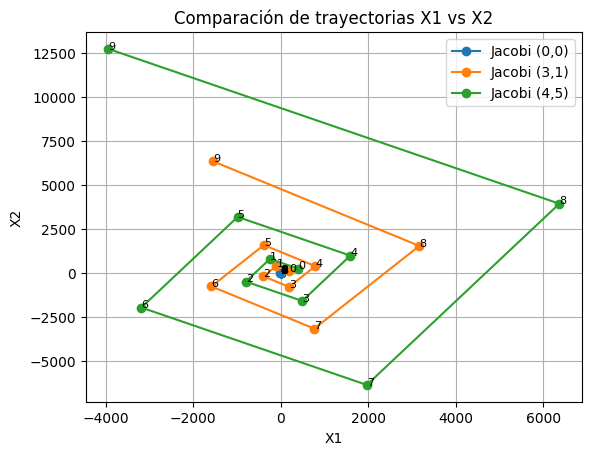

In [42]:
graficar_multiples_historiales(
    [historial_x_solutions_jacobi2, historial_x_solutions_jacobi21, historial_x_solutions_jacobi22], 
    ["Jacobi (0,0)", "Jacobi (3,1)", "Jacobi (4,5)"]
)

### Metodo Gauss-Seidel

In [47]:
A=np.array([[1, 1],
            [-2, 1]], dtype=float)
b=np.array([6, 0], dtype=float)
n=1
solution212, historial_x_solutions_seidel21 = gauss_seidel(A=A, b=b, x=[4,10] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:38:22][INFO][NattyrdGT] i= 0 x: [[ 4. 10.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 1 x: [[-4. -8.]]


[01-20 21:38:22][INFO][NattyrdGT] i= 2 x: [[14. 28.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 3 x: [[-22. -44.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 4 x: [[ 50. 100.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 5 x: [[ -94. -188.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 6 x: [[194. 388.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 7 x: [[-382. -764.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 8 x: [[ 770. 1540.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 9 x: [[-1534. -3068.]]
[01-20 21:38:22][INFO][NattyrdGT] i= 10 x: [[3074. 6148.]]


In [48]:
A=np.array([[1, 1],
            [-2, 1]], dtype=float)
b=np.array([6, 0], dtype=float)
n=1
solution212, historial_x_solutions_seidel211 = gauss_seidel(A=A, b=b, x=[8,8] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:38:24][INFO][NattyrdGT] i= 0 x: [[8. 8.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 1 x: [[-2. -4.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 2 x: [[10. 20.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 3 x: [[-14. -28.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 4 x: [[34. 68.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 5 x: [[ -62. -124.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 6 x: [[130. 260.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 7 x: [[-254. -508.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 8 x: [[ 514. 1028.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 9 x: [[-1022. -2044.]]
[01-20 21:38:24][INFO][NattyrdGT] i= 10 x: [[2050. 4100.]]


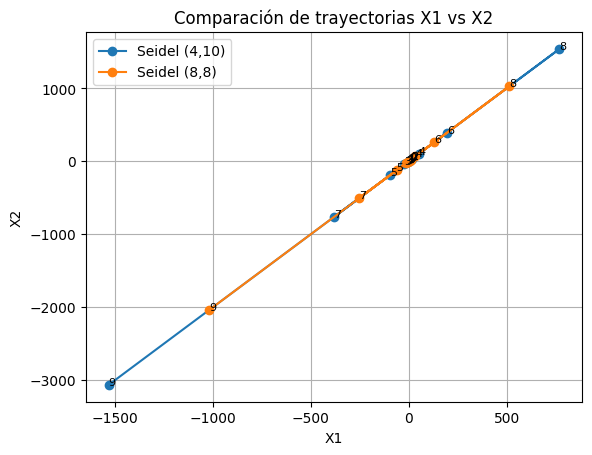

In [49]:
graficar_multiples_historiales(
    [historial_x_solutions_seidel21, historial_x_solutions_seidel211],
    ["Seidel (4,10)", "Seidel (8,8)"]
)

### EJERCICIO 3

![Descripción](img3.png)


### Metodo de Gauss-Seidel

In [73]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_convergencia_4x4_numerada(historial_x):
    """
    Grafica la convergencia de un sistema 4x4.
    Cada punto está numerado según la iteración.
    
    Parameters
    ----------
    historial_x : list
        Lista de vectores x (cada uno de tamaño 4)
    """

    historial_x = np.array(historial_x)

    if historial_x.shape[1] != 4:
        raise ValueError("Este método está diseñado solo para sistemas 4x4")

    iteraciones = range(len(historial_x))

    fig, axs = plt.subplots(2, 2, figsize=(11, 9))
    fig.suptitle("Convergencia del sistema 4x4 (iteraciones numeradas)")

    etiquetas = ["X1", "X2", "X3", "X4"]

    for i, ax in enumerate(axs.flat):
        ax.plot(iteraciones, historial_x[:, i], marker='o')

        # Numerar cada punto
        for k in iteraciones:
            ax.text(
                k,
                historial_x[k, i],
                f'{k}',
                fontsize=9,
                ha='right',
                va='bottom'
            )

        ax.set_xlabel("Iteraciones")
        ax.set_ylabel(etiquetas[i])
        ax.grid(True)

    plt.tight_layout()
    plt.show()



In [52]:
import numpy as np

A = np.array([
    [ 1, -1,  2,  0],
    [-1,  1, -1,  3],
    [ 2, -1,  1, -1],
    [ 0,  3, -1,  2]
], dtype=float)

b = np.array([
    1360,
    1130,
    1350,
    3650
], dtype=float)
n=1
solution2122, historial_x_solutions_seidel2112 = gauss_seidel(A=A, b=b, x=[4,2,3,1] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:43:27][INFO][NattyrdGT] i= 0 x: [[4. 2. 3. 1.]]
[01-20 21:43:27][INFO][NattyrdGT] i= 1 x: [[ 1356.   2486.   1125.  -1341.5]]
[01-20 21:43:27][INFO][NattyrdGT] i= 2 x: [[ 1596.    7875.5   4692.   -7642.25]]
[01-20 21:43:27][INFO][NattyrdGT] i= 3 x: [[  -148.5    28600.25   22605.    -29772.875]]
[01-20 21:43:27][INFO][NattyrdGT] i= 4 x: [[-15249.75    97803.875   99880.5    -94940.5625]]
[01-20 21:43:27][INFO][NattyrdGT] i= 5 x: [[-100597.125    285235.0625   392838.75    -229608.21875]]
[01-20 21:43:27][INFO][NattyrdGT] i= 6 x: [[-499082.4375    583710.96875  1353617.625    -196932.640625]]
[01-20 21:43:27][INFO][NattyrdGT] i= 7 x: [[-2122164.28125    -176618.734375   3872127.1875     2202816.6953125]]
[01-20 21:43:27][INFO][NattyrdGT] i= 8 x: [[ -7919513.109375   -10654706.0078125    7388486.90625
   19678127.46484375]]
[01-20 21:43:27][INFO][NattyrdGT] i= 9 x: [[-2.54303198e+07 -7.70750853e+07 -6.53496820e+06  1.12346969e+08]]
[01-20 21:43:27][INFO][NattyrdGT] i= 10 x: [[

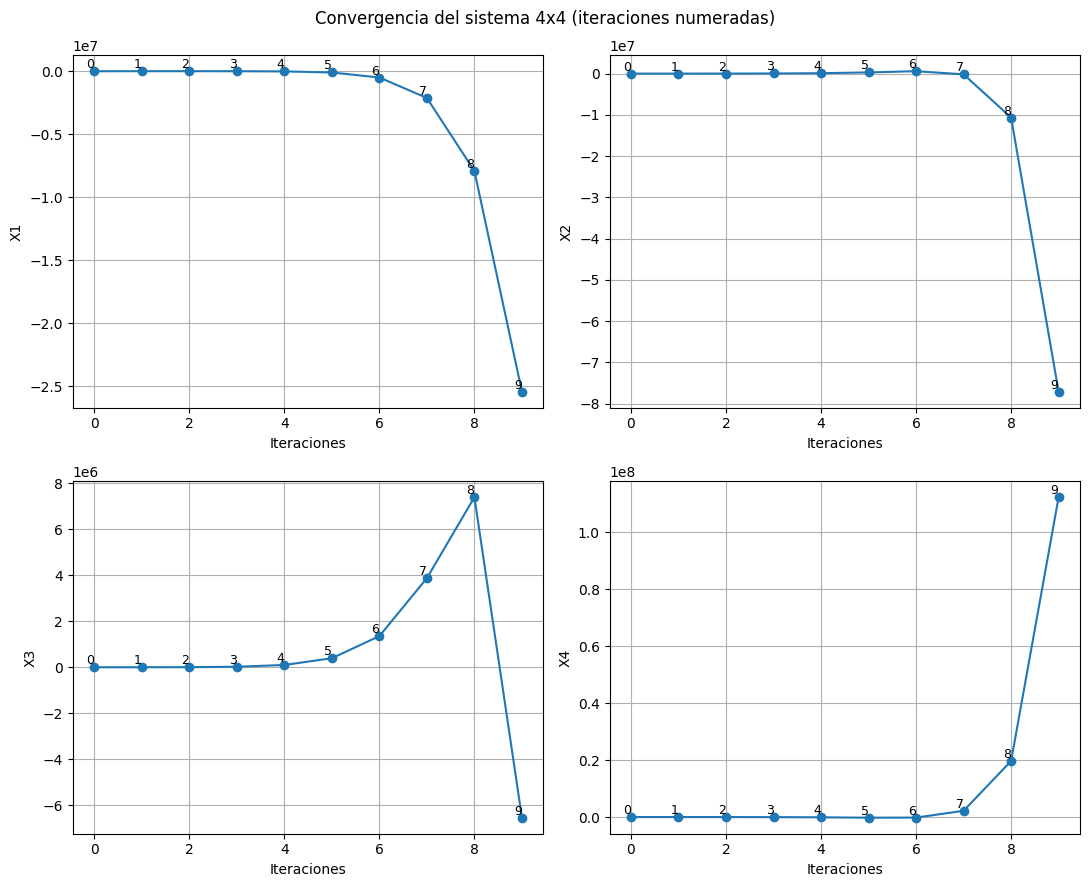

In [79]:
graficar_convergencia_4x4_numerada(historial_x_solutions_seidel2112)

In [53]:
A = np.array([
    [ 1, -1,  2,  0],
    [-1,  1, -1,  3],
    [ 2, -1,  1, -1],
    [ 0,  3, -1,  2]
], dtype=float)

b = np.array([
    1360,
    1130,
    1350,
    3650
], dtype=float)
n=1
solution21221, historial_x_solutions_seidel21121 = gauss_seidel(A=A, b=b, x=[2,1,0,3] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:44:28][INFO][NattyrdGT] i= 0 x: [[2. 1. 0. 3.]]
[01-20 21:44:28][INFO][NattyrdGT] i= 1 x: [[ 1361.   2482.   1113.  -1341.5]]
[01-20 21:44:28][INFO][NattyrdGT] i= 2 x: [[ 1616.    7883.5   4660.   -7670.25]]
[01-20 21:44:28][INFO][NattyrdGT] i= 3 x: [[   -76.5    28724.25   22557.    -29982.875]]
[01-20 21:44:28][INFO][NattyrdGT] i= 4 x: [[-15029.75    98605.875  100032.5    -96067.5625]]
[01-20 21:44:28][INFO][NattyrdGT] i= 5 x: [[-100099.125    289266.0625   394746.75    -234700.71875]]
[01-20 21:44:28][INFO][NattyrdGT] i= 6 x: [[-498867.4375    601111.46875  1365495.625    -217094.390625]]
[01-20 21:44:28][INFO][NattyrdGT] i= 7 x: [[-2128519.78125    -110610.984375   3930684.1875     2133083.5703125]]
[01-20 21:44:28][INFO][NattyrdGT] i= 8 x: [[ -7970619.359375   -10438055.8828125    7637616.40625
   19477717.02734375]]
[01-20 21:44:28][INFO][NattyrdGT] i= 9 x: [[-2.57119287e+07 -7.65063334e+07 -5.60340895e+06  1.11959621e+08]]
[01-20 21:44:28][INFO][NattyrdGT] i= 10 x: [[

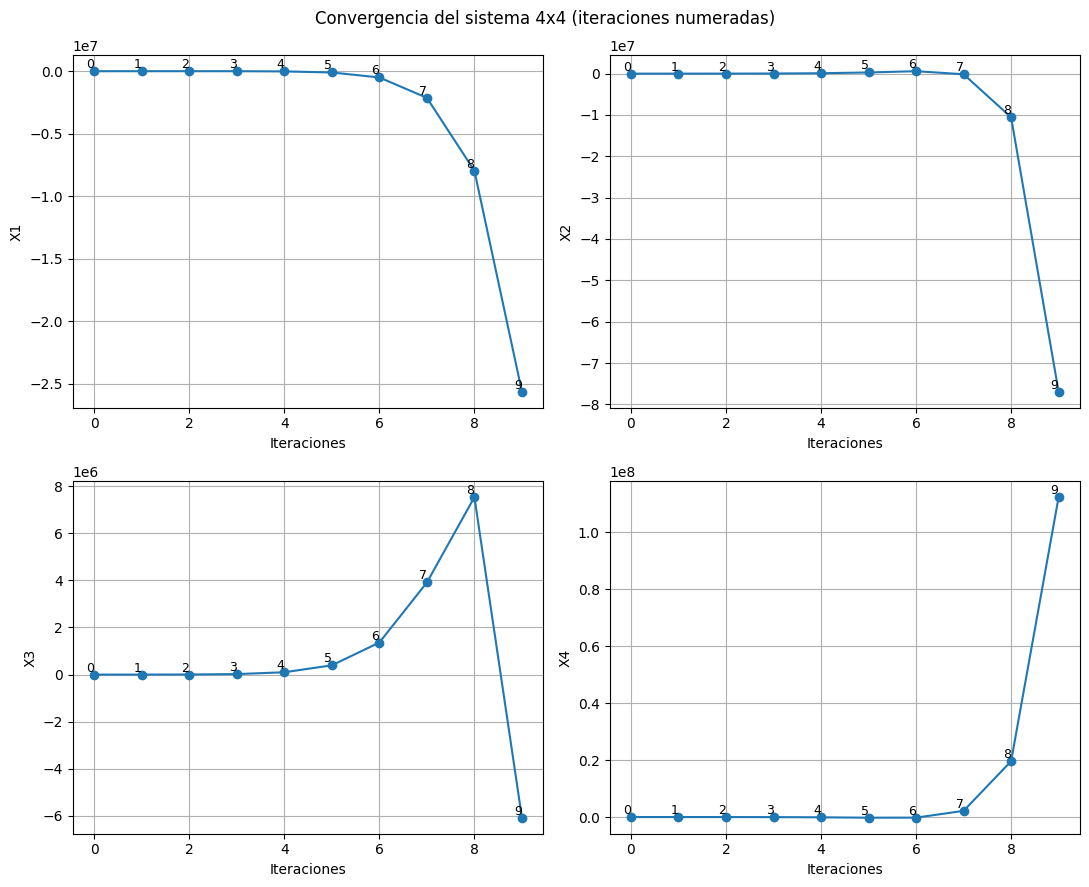

In [78]:
graficar_convergencia_4x4_numerada(historial_x_solutions_seidel21121)

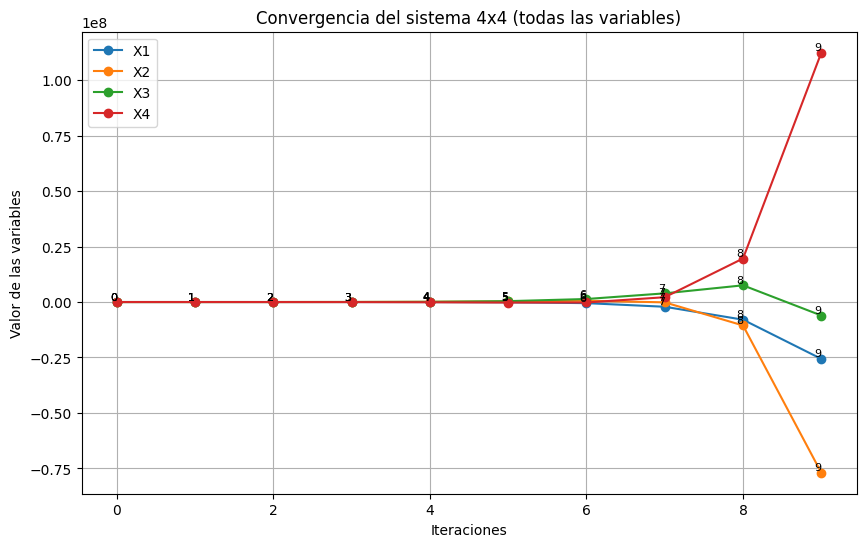

In [81]:
graficar_4x4_en_un_solo_grafico(historial_x_solutions_seidel21121)

In [69]:
A = np.array([
    [ 1, -1,  2,  0],
    [-1,  1, -1,  3],
    [ 2, -1,  1, -1],
    [ 0,  3, -1,  2]
], dtype=float)

b = np.array([
    1360,
    1130,
    1350,
    3650
], dtype=float)
n=1
solution211221, historial_x_solutions_seidel211221 = gauss_seidel(A=A, b=b, x=[0.25,0.25,0.25,0.25] * n, tol=1e-5, max_iter=10)  # type: ignore

[01-20 21:51:34][INFO][NattyrdGT] i= 0 x: [[0.25 0.25 0.25 0.25]]
[01-20 21:51:34][INFO][NattyrdGT] i= 1 x: [[ 1359.75   2489.25   1120.    -1348.875]]
[01-20 21:51:34][INFO][NattyrdGT] i= 2 x: [[ 1609.25    7905.875   4688.5    -7689.5625]]


[01-20 21:51:34][INFO][NattyrdGT] i= 3 x: [[  -111.125    28776.0625   22658.75    -30009.71875]]
[01-20 21:51:34][INFO][NattyrdGT] i= 4 x: [[-15181.4375    98636.46875  100339.625    -95959.890625]]
[01-20 21:51:34][INFO][NattyrdGT] i= 5 x: [[-100682.78125    288666.515625   395422.1875    -233463.6796875]]
[01-20 21:51:34][INFO][NattyrdGT] i= 6 x: [[-500817.859375    596125.3671875  1365647.40625    -209539.34765625]]
[01-20 21:51:34][INFO][NattyrdGT] i= 7 x: [[-2133809.4453125   -138413.99609375  3921015.546875    2169953.76757812]]
[01-20 21:51:34][INFO][NattyrdGT] i= 8 x: [[ -7979085.08984375 -10566800.84570312   7562673.1015625
   19633362.81933594]]
[01-20 21:51:34][INFO][NattyrdGT] i= 9 x: [[-2.56907870e+07 -7.70270724e+07 -6.01078549e+06  1.12537041e+08]]
[01-20 21:51:34][INFO][NattyrdGT] i= 10 x: [[-6.50041414e+07 -4.08624920e+08 -1.66078246e+08  5.29900081e+08]]


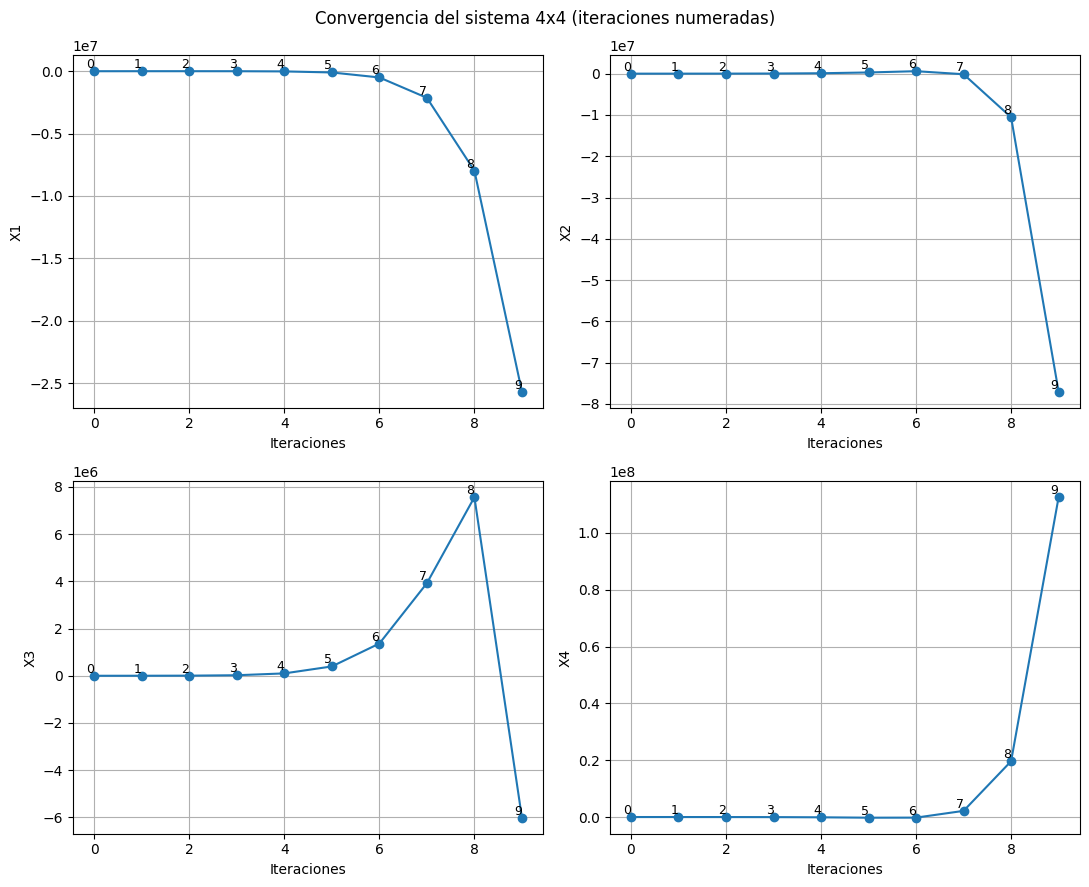

In [74]:
graficar_convergencia_4x4_numerada(historial_x_solutions_seidel211221)

In [75]:
import numpy as np
import matplotlib.pyplot as plt

def graficar_4x4_en_un_solo_grafico(historial_x):
    """
    Grafica X1, X2, X3 y X4 en un solo gráfico,
    numerando cada punto según la iteración.

    Parameters
    ----------
    historial_x : list
        Lista de vectores x (cada uno de tamaño 4)
    """

    historial_x = np.array(historial_x)

    if historial_x.shape[1] != 4:
        raise ValueError("Este método es solo para sistemas 4x4")

    iteraciones = range(len(historial_x))
    etiquetas = ["X1", "X2", "X3", "X4"]

    plt.figure(figsize=(10, 6))

    for i in range(4):
        plt.plot(iteraciones, historial_x[:, i], marker='o', label=etiquetas[i])

        # Numerar cada punto
        for k in iteraciones:
            plt.text(
                k,
                historial_x[k, i],
                f'{k}',
                fontsize=8,
                ha='right',
                va='bottom'
            )

    plt.xlabel("Iteraciones")
    plt.ylabel("Valor de las variables")
    plt.title("Convergencia del sistema 4x4 (todas las variables)")
    plt.legend()
    plt.grid(True)
    plt.show()


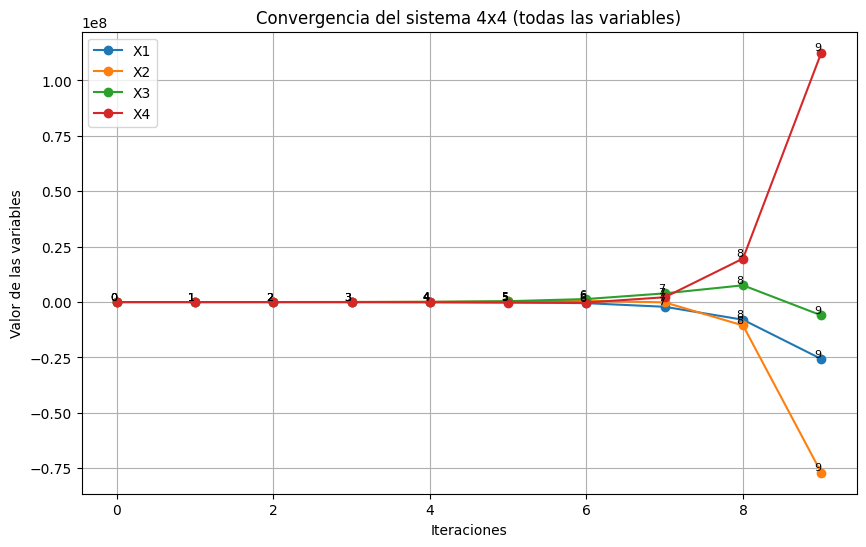

In [77]:
graficar_4x4_en_un_solo_grafico(historial_x_solutions_seidel211221)